In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving day.csv to day.csv
Saving hour.csv to hour.csv


In [ ]:
df = pd.read_csv('/content/hour.csv')

In [ ]:
print(df.head())
print(df.isnull().sum())

   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81        0.0       3          13   16  
1           1  0.22  0.2727  0.80        0.0       8          32   40  
2           1  0.22  0.2727  0.80        0.0       5          27   32  
3           1  0.24  0.2879  0.75        0.0       3          10   13  
4           1  0.24  0.2879  0.75        0.0       0           1    1  
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
hol

In [ ]:
df['cnt'] = pd.cut(df['cnt'], bins=3, labels=[0,1,2])

In [ ]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


In [ ]:
X = df.drop(['cnt','instant','dteday','casual','registered'], axis=1)
y = df['cnt']
feature_names = X.columns

In [ ]:
df = pd.read_csv('/content/day.csv')

In [ ]:
print(df.head())
print(df.isnull().sum())


   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  
instant       0
dteday    

In [ ]:
df['cnt'] = pd.cut(df['cnt'], bins=3, labels=[0,1,2])

In [ ]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop(['cnt','instant','dteday','casual','registered'], axis=1)
y = df['cnt']
feature_names = X.columns

In [ ]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train1 = scaler.fit_transform(X_train1)
X_test1 = scaler.transform(X_test1)

model = RandomForestClassifier()   # 🔁 change model

model.fit(X_train1, y_train1)
y_pred1 = model.predict(X_test1)

print("\n===== 80:20 SPLIT =====")
print("Accuracy:", accuracy_score(y_test1, y_pred1))


===== 80:20 SPLIT =====
Accuracy: 0.8503401360544217


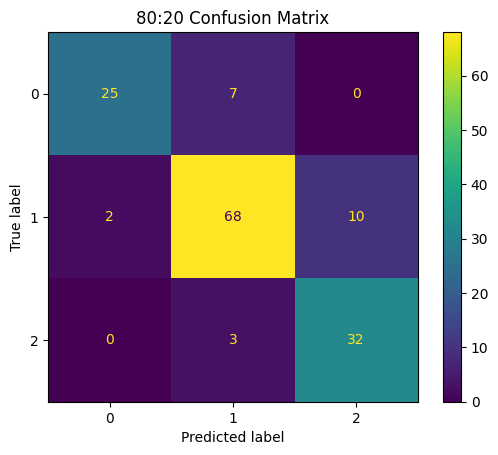

In [ ]:
ConfusionMatrixDisplay(confusion_matrix(y_test1, y_pred1)).plot()
plt.title("80:20 Confusion Matrix")
plt.show()

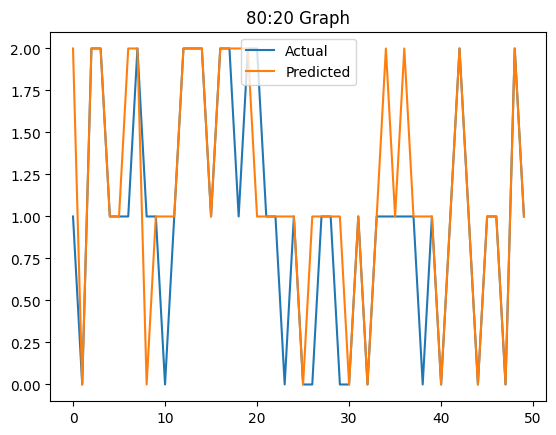

In [ ]:
plt.plot(y_test1.values[:50], label="Actual")
plt.plot(y_pred1[:50], label="Predicted")
plt.legend()
plt.title("80:20 Graph")
plt.show()

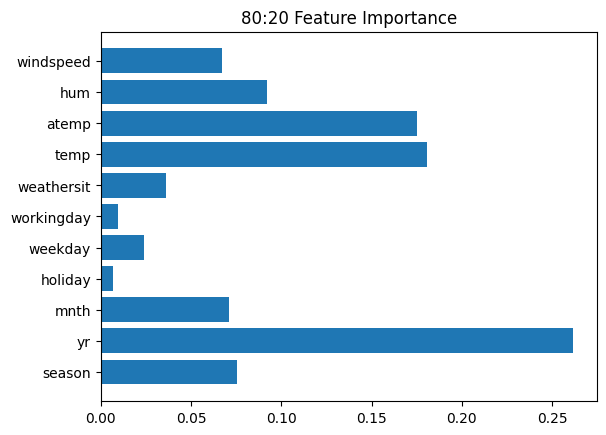

In [ ]:
if hasattr(model, "feature_importances_"):
    plt.barh(feature_names, model.feature_importances_)
    plt.title("80:20 Feature Importance")
    plt.show()

In [ ]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.3)

X_train2 = scaler.fit_transform(X_train2)
X_test2 = scaler.transform(X_test2)

model.fit(X_train2, y_train2)
y_pred2 = model.predict(X_test2)

print("\n===== 70:30 SPLIT =====")
print("Accuracy:", accuracy_score(y_test2, y_pred2))



===== 70:30 SPLIT =====
Accuracy: 0.8590909090909091


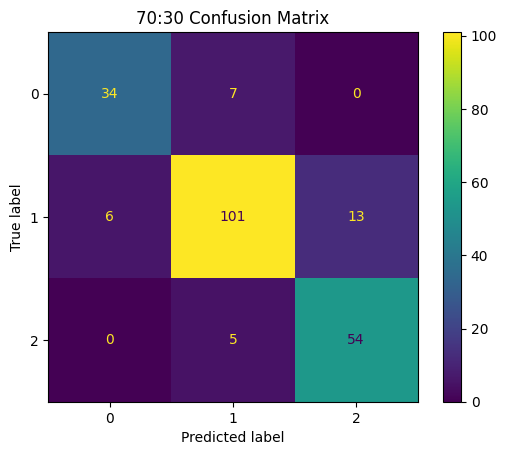

In [ ]:
ConfusionMatrixDisplay(confusion_matrix(y_test2, y_pred2)).plot()
plt.title("70:30 Confusion Matrix")
plt.show()

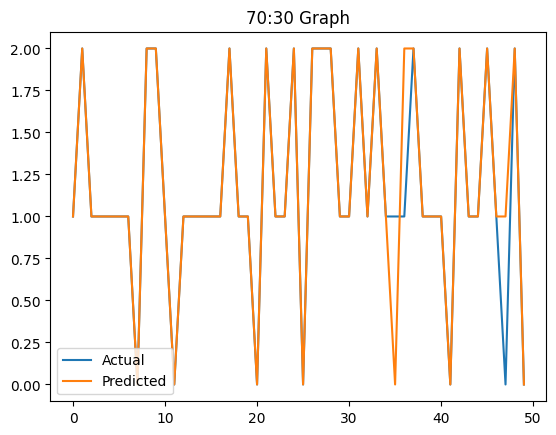

In [ ]:
plt.plot(y_test2.values[:50], label="Actual")
plt.plot(y_pred2[:50], label="Predicted")
plt.legend()
plt.title("70:30 Graph")
plt.show()

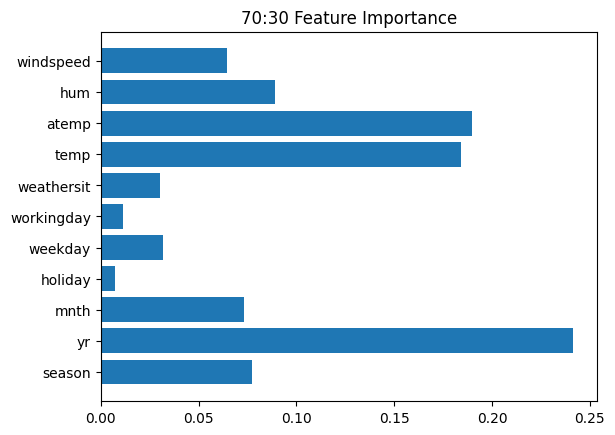

In [ ]:
if hasattr(model, "feature_importances_"):
    plt.barh(feature_names, model.feature_importances_)
    plt.title("70:30 Feature Importance")
    plt.show()

In [ ]:
X = df.drop('cnt', axis=1)
y = df['cnt']

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
# 80:20 Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("80:20 Results")
print(accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, average='weighted'),
      recall_score(y_test, y_pred, average='weighted'), f1_score(y_test, y_pred, average='weighted'))

80:20 Results
0.019275028768699656 0.009639737284893939 0.019275028768699656 0.010004912527914312


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
